### Module Import

In [1]:
# https://github.com/HideOnHouse/TorchBase

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from dataset import *
from model import get_Model
from learning import *
from inference import *

torch.__version__

'1.11.0+cu102'

### 함수 선언

In [2]:
def label2int(data, label_tags):
    for i in range(len(data)):
        data.iloc[i,1] = label_tags.index(data.iloc[i, 1])
    return data


def draw_history(history):
    train_loss = history["train_loss"]
    train_acc = history["train_acc"]
    valid_loss = history["valid_loss"]
    valid_acc = history["valid_acc"]

    plt.subplot(2,1,1)
    plt.title("Loss")
    plt.plot(train_loss, label="train")
    plt.plot(valid_loss, label="valid")
    plt.legend()

    plt.subplot(2,1,2)
    plt.title('Accuracy')
    plt.plot(train_acc, label="train")
    plt.plot(valid_acc, label="valid")
    plt.legend()

    plt.show()

In [3]:
# label_tags
label_tags = ['불안', '슬픔', '상처', '당황', '분노', '기쁨']

train_path = "train.csv"
test_path = "test.csv"

train_data = pd.read_csv(train_path, encoding='cp949')
test_data = pd.read_csv(test_path, encoding='cp949')

train_data = label2int(train_data, label_tags)
test_data = label2int(test_data, label_tags)

# your Data Pre-Processing
train_x, train_y = train_data.iloc[:, :1], train_data.iloc[:, 1:]
test_x, test_y = test_data.iloc[:, :1], test_data.iloc[:, 1:]

# data split
train_x, valid_x, train_y, valid_y = train_test_split(train_x, train_y, stratify=train_y, random_state=17, test_size=0.05)

# Check Train, Valid, Test Image's Shape
print("The Shape of Train Input: ", train_x.shape)
print("The Shape of Valid Input: ", valid_x.shape)
print("The Shape of Test Input: ", test_x.shape)

# Check Train, Valid Label's Shape
print("The Shape of Train Labels: ", train_y.shape)
print("The Shape of Valid Labels: ", valid_y.shape)
print("The Shape of Valid Labels: ", test_y.shape)

The Shape of Train Input:  (9405, 1)
The Shape of Valid Input:  (495, 1)
The Shape of Test Input:  (100, 1)
The Shape of Train Labels:  (9405, 1)
The Shape of Valid Labels:  (495, 1)
The Shape of Valid Labels:  (100, 1)


## Model 1
+ basis Model

### Klue BERT-base

In [4]:
model_path = "klue/bert-base"

train_dataset = MyDataset(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

Downloading:   0%|          | 0.00/289 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/425 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/243k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/483k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [5]:
class_name = "MyModel_1"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

device

Downloading:   0%|          | 0.00/424M [00:00<?, ?B/s]

Some weights of the model checkpoint at klue/bert-base were not used when initializing BertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


'cuda'

In [6]:
# train
print("============================= Train =============================")
history = train(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [01:41,  2.90it/s, epoch=1/10, loss=0.038116, acc=0.556]
16it [00:01,  8.05it/s, loss=0.032457, acc=0.634]

294it [01:42,  2.87it/s, epoch=2/10, loss=0.028092, acc=0.687]
16it [00:01,  8.35it/s, loss=0.033332, acc=0.636]

294it [01:43,  2.85it/s, epoch=3/10, loss=0.021186, acc=0.779]
16it [00:01,  8.29it/s, loss=0.033248, acc=0.638]

294it [01:43,  2.84it/s, epoch=4/10, loss=0.015238, acc=0.849]
16it [00:01,  8.29it/s, loss=0.035798, acc=0.663]

294it [01:43,  2.84it/s, epoch=5/10, loss=0.010249, acc=0.902]
16it [00:01,  8.20it/s, loss=0.043297, acc=0.644]

294it [01:43,  2.83it/s, epoch=6/10, loss=0.006966, acc=0.934]
16it [00:02,  7.94it/s, loss=0.047157, acc=0.655]

294it [01:44,  2.82it/s, epoch=7/10, loss=0.005321, acc=0.948]
16it [00:01,  8.10it/s, loss=0.051328, acc=0.655]

294it [01:44,  2.82it/s, epoch=8/10, loss=0.003899, acc=0.962]
16it [00:02,  8.00it/s, loss=0.052913, acc=0.620]

294it [01:43,  2.83it/

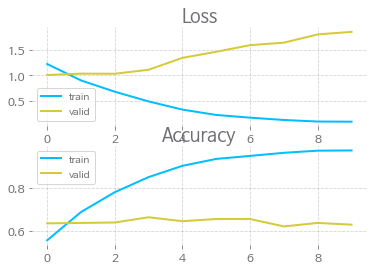

In [7]:
draw_history(history)

In [8]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:00,  9.32it/s, loss=0.058254, acc=0.610]
test loss : 1.456355
test acc : 0.610


In [10]:
file_name = class_name
torch.save(model, f"models/{file_name}_bert.pt")
with open(f"models/{file_name}_bert_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

### Klue RoBerta-base

In [11]:
model_path = "klue/roberta-base"

train_dataset = MyDataset(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

Downloading:   0%|          | 0.00/375 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/243k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/734k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/173 [00:00<?, ?B/s]

In [12]:
class_name = "MyModel_1"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

device

Downloading:   0%|          | 0.00/546 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/422M [00:00<?, ?B/s]

Some weights of the model checkpoint at klue/roberta-base were not used when initializing RobertaModel: ['lm_head.bias', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.decoder.weight', 'lm_head.dense.bias', 'lm_head.decoder.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for

'cuda'

In [13]:
# train
print("============================= Train =============================")
history = train(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [01:41,  2.88it/s, epoch=1/10, loss=0.040282, acc=0.527]
16it [00:01,  8.25it/s, loss=0.033910, acc=0.636]

294it [01:43,  2.85it/s, epoch=2/10, loss=0.031772, acc=0.644]
16it [00:01,  8.23it/s, loss=0.032376, acc=0.626]

294it [01:42,  2.86it/s, epoch=3/10, loss=0.027916, acc=0.692]
16it [00:01,  8.25it/s, loss=0.031375, acc=0.651]

294it [01:42,  2.86it/s, epoch=4/10, loss=0.023869, acc=0.745]
16it [00:01,  8.12it/s, loss=0.033458, acc=0.665]

294it [01:42,  2.86it/s, epoch=5/10, loss=0.020044, acc=0.791]
16it [00:01,  8.38it/s, loss=0.033433, acc=0.673]

294it [01:42,  2.88it/s, epoch=6/10, loss=0.015963, acc=0.838]
16it [00:01,  8.38it/s, loss=0.040495, acc=0.644]

294it [01:42,  2.87it/s, epoch=7/10, loss=0.012705, acc=0.872]
16it [00:01,  8.41it/s, loss=0.040928, acc=0.646]

294it [01:42,  2.87it/s, epoch=8/10, loss=0.010015, acc=0.902]
16it [00:01,  8.16it/s, loss=0.043346, acc=0.651]

294it [01:42,  2.87it/

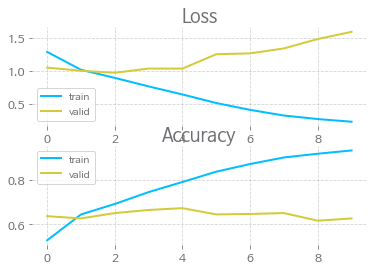

In [14]:
draw_history(history)

In [15]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:00, 10.18it/s, loss=0.045535, acc=0.580]
test loss : 1.138378
test acc : 0.580


In [17]:
file_name = class_name
torch.save(model, f"models/{file_name}_roberta.pt")
with open(f"models/{file_name}_roberta_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)